In [1]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
from scipy.spatial import ConvexHull
from scipy.optimize import linprog
from pycvxset import Polytope




A = np.array([[1, 1], [0, 1]])
B = np.array([[0.5], [1]])
d = 2  
m = 1  

K = np.array([[-0.5, -1.0]])
A_K = A + B @ K

x0 = np.array([-5, -2])

w = 0.15
W_bounds = np.array([[-w, w], [-w, w]])



N = 10  # prediction horizon
Q = np.eye(2) 
R = 0.1 * np.eye(1)  
gamma = 0.01  

# State constraints 
# X = {x : max{x1-2, -x1-10, x2-2, -x2-2} <= 0}
X_A = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]])
X_b = np.array([2, 8, 3, 2])

# Input constraints
U_min = -1.0
U_max = 1.0



In [2]:

def generate_noise_samples(n_samples, W_bounds):
    w_samples = np.random.uniform(
        W_bounds[:, 0], W_bounds[:, 1], (n_samples, d)
    )
    return w_samples

def generate_noise_trajectories(n_traj, horizon, n0_samples, W_bounds):
    
    w_samples = generate_noise_samples(n0_samples, W_bounds)
    w_trajectories = []
    
    for i in range(n_traj):
        traj = []
        for t in range(horizon):
            # Randomly select from available samples
            idx = np.random.randint(0, n0_samples)
            traj.append(w_samples[idx])
        w_trajectories.append(np.array(traj))
    
    return w_trajectories


#  D_{t-1} = [I, A_K, A_K^2, ..., A_K^{t-1}]
def D_matrix(t, A_K):
    
    if t == 0:
        return np.zeros((d, 0))
    
    D = np.zeros((d, d * t))
    for k in range(t):
        A_K_power = np.linalg.matrix_power(A_K, k)
        D[:, k*d:(k+1)*d] = A_K_power
    
    return D



def compute_error_samples(w_trajectories, t, A_K):
    """Compute error state samples e_t = D_{t-1} @ w_{[t-1]}"""
    if t == 0:
        return np.zeros((len(w_trajectories), d))
    
    D = D_matrix(t, A_K)
    e_samples = []
    
    for w_traj in w_trajectories:
        # Flatten noise trajectory w_{[t-1]} = [w_{t-1}, ..., w_0]
        w_flat = w_traj[:t].flatten()[::-1]  # reverse order
        e = D @ w_flat
        e_samples.append(e)
    
    return np.array(e_samples)


#  E_t = D_{t-1} @ W^t robust tube set
def robust_tube(t, A_K, W_bounds):
    
    if t == 0:
        return np.zeros((1, d))
    
    D = D_matrix(t, A_K)
    
    # vertices of W^t (product space)
    from itertools import product
    all_vertices = []
    for combo in product([0, 1], repeat=t*d):
        vertex = []
        for i in range(t):
            for j in range(d):
                idx = i * d + j
                vertex.append(W_bounds[j, combo[idx]])
        all_vertices.append(vertex)
    
    all_vertices = np.array(all_vertices)
    
    E_vertices = (D @ all_vertices.T).T
    
    return E_vertices

def compute_tightened_input_constraint(E_vertices, K, U_min, U_max):

    K_e = (K @ E_vertices.T).flatten()
    u_min_tight = U_min - np.min(K_e)
    u_max_tight = U_max - np.max(K_e)
    
    return u_min_tight, u_max_tight


def pontryagin_difference(A_outer, b_outer, A_inner, b_inner):
    
    
    P1 = Polytope(A=A_outer, b=b_outer)
    P2 = Polytope(A=A_inner, b=b_inner)
    P_diff = P1 - P2
    A_diff, b_diff = P_diff.A, P_diff.b

    return A_outer, b_diff



# Terminal invariant set Zf
#  K*Zf                in  U - K*E_N
#  A_K*Zf +  A_K^N*W   in  Zf
#  Zf                  in  Z_N
    
#  Returns: A_f, b_f such that Zf = {z: A_f @ z <= b_f}

def terminal_set(A_K, N, X_A, X_b, K, U_min, U_max, W_bounds):


    # Start with tightened state constraints Z_N
    # For simplicity, we'll compute a robust positive invariant (RPI) set
    # using iterative Pontryagin difference
    
    # Compute E_N
    E_N_vertices = robust_tube(N, A_K, W_bounds)
    
    # Get polytope representation of E_N
    if E_N_vertices.shape[0] > d:
        try:
            hull = ConvexHull(E_N_vertices)
            A_E_N = hull.equations[:, :-1]
            b_E_N = -hull.equations[:, -1]
        except:
            # Fallback: use bounding box
            E_min = np.min(E_N_vertices, axis=0)
            E_max = np.max(E_N_vertices, axis=0)
            A_E_N = np.vstack([np.eye(d), -np.eye(d)])
            b_E_N = np.hstack([E_max, -E_min])
    else:
        E_min = np.min(E_N_vertices, axis=0)
        E_max = np.max(E_N_vertices, axis=0)
        A_E_N = np.vstack([np.eye(d), -np.eye(d)])
        b_E_N = np.hstack([E_max, -E_min])
    
    # Start with X ⊖ E_N as initial approximation
    A_f, b_f = pontryagin_difference(X_A, X_b, A_E_N, b_E_N)
    
    # Compute A_K^N * W
    A_K_N = np.linalg.matrix_power(A_K, N)
    W_vertices = np.array([
        [W_bounds[0, 0], W_bounds[1, 0]],
        [W_bounds[0, 0], W_bounds[1, 1]],
        [W_bounds[0, 1], W_bounds[1, 0]],
        [W_bounds[0, 1], W_bounds[1, 1]]
    ])
    A_K_N_W_vertices = (A_K_N @ W_vertices.T).T
    
    # Get polytope for A_K^N * W
    if A_K_N_W_vertices.shape[0] > d:
        try:
            hull = ConvexHull(A_K_N_W_vertices)
            A_AKW = hull.equations[:, :-1]
            b_AKW = -hull.equations[:, -1]
        except:
            AKW_min = np.min(A_K_N_W_vertices, axis=0)
            AKW_max = np.max(A_K_N_W_vertices, axis=0)
            A_AKW = np.vstack([np.eye(d), -np.eye(d)])
            b_AKW = np.hstack([AKW_max, -AKW_min])
    else:
        AKW_min = np.min(A_K_N_W_vertices, axis=0)
        AKW_max = np.max(A_K_N_W_vertices, axis=0)
        A_AKW = np.vstack([np.eye(d), -np.eye(d)])
        b_AKW = np.hstack([AKW_max, -AKW_min])
    
    # Iteratively compute invariant set: Zf_{k+1} = (A_K^{-1} * (Zf_k - A_K^N*W)) intersection Zf_k
    max_iterations = 50
    tolerance = 1e-6
    
    for iteration in range(max_iterations):
        b_f_old = b_f.copy()
        
        # Compute Zf ⊖ A_K^N*W
        A_temp, b_temp = pontryagin_difference(A_f, b_f, A_AKW, b_AKW)
        
        # Compute A_K^{-1} * (Zf - A_K^N*W)
        # This is {z : A_K*z ∈ Zf - A_K^N*W} = {z : A_temp @ A_K @ z <= b_temp}
        A_pre = A_temp @ A_K
        b_pre = b_temp
        
        # Intersect with original Zf
        A_f = np.vstack([A_f, A_pre])
        b_f = np.hstack([b_f, b_pre])
        
        # Remove redundant constraints (simplified version)
        # Keep only unique rows
        unique_constraints = []
        for i in range(len(b_f)):
            is_redundant = False
            for j in range(i):
                if np.allclose(A_f[i], A_f[j]) and np.isclose(b_f[i], b_f[j]):
                    is_redundant = True
                    break
            if not is_redundant:
                unique_constraints.append(i)
        
        A_f = A_f[unique_constraints]
        b_f = b_f[unique_constraints]
        
        # Check convergence
        if iteration > 0 and np.max(np.abs(b_f_old[:len(b_f)] - b_f[:len(b_f_old)])) < tolerance:
            print(f"  Terminal set converged in {iteration+1} iterations")
            break
    
    # Verify input constraints: K*Zf in U - K*E_N
    u_min_tight, u_max_tight = compute_tightened_input_constraint(E_N_vertices, K, U_min, U_max)
    
    # Add input constraints K*z >= u_min_tight and K*z <= u_max_tight
    A_f = np.vstack([A_f, K, -K])
    b_f = np.hstack([b_f, u_max_tight, -u_min_tight])
    
    print(f"  Terminal set has {len(b_f)} constraints")
    
    return A_f, b_f



# Compute tightened constraint set Z_k as per equation (11):
# Z_k = intersection _{p=1}^k (Gamma_p - (+_{r=p}^{k-1} A_K^r * W))

# def compute_Z_k_tightened(k, w_trajectories, epsilon, A_K, X_A, X_b, W_bounds, gamma):
    
#     # This is a simplified version
#     # Full implementation would iterate over all p and compute intersections
    
#     # Start with Γ_k (which we approximate with relaxed state constraints)
#     A_k = X_A.copy()
#     b_k = X_b.copy()
    
#     # Tighten for accumulated disturbances
#     if k > 0:
#         # Compute union of tubes from p to k-1
#         for p in range(1, k+1):
#             # Compute ⊕_{r=p}^{k-1} A_K^r * W
#             tube_sum_vertices = np.zeros((1, d))
            
#             for r in range(p, k):
#                 A_K_r = np.linalg.matrix_power(A_K, r)
#                 W_vertices = np.array([
#                     [W_bounds[0, 0], W_bounds[1, 0]],
#                     [W_bounds[0, 0], W_bounds[1, 1]],
#                     [W_bounds[0, 1], W_bounds[1, 0]],
#                     [W_bounds[0, 1], W_bounds[1, 1]]
#                 ])
#                 scaled_vertices = (A_K_r @ W_vertices.T).T
                
#                 # Minkowski sum (approximate by taking all pairwise sums)
#                 if tube_sum_vertices.shape[0] == 1 and np.allclose(tube_sum_vertices[0], 0):
#                     tube_sum_vertices = scaled_vertices
#                 else:
#                     new_vertices = []
#                     for v1 in tube_sum_vertices:
#                         for v2 in scaled_vertices:
#                             new_vertices.append(v1 + v2)
#                     tube_sum_vertices = np.array(new_vertices)
            
#             # Get polytope representation
#             if tube_sum_vertices.shape[0] > d:
#                 try:
#                     hull = ConvexHull(tube_sum_vertices)
#                     A_tube = hull.equations[:, :-1]
#                     b_tube = -hull.equations[:, -1]
#                 except:
#                     tube_min = np.min(tube_sum_vertices, axis=0)
#                     tube_max = np.max(tube_sum_vertices, axis=0)
#                     A_tube = np.vstack([np.eye(d), -np.eye(d)])
#                     b_tube = np.hstack([tube_max, -tube_min])
                
#                 # Pontryagin difference
#                 A_k, b_k = pontryagin_difference(A_k, b_k, A_tube, b_tube)
    
#     return A_k, b_k

def compute_hp_support(p, k, alpha_j, A_K, W_bounds):
    """
    Computes the exact tightening scalar h_p(alpha_j) for the accumulated noise tube:
    h_p(alpha_j) = sup { alpha_j^T * xi | xi in ⊕_{r=p}^{k-1} A_K^r * W }
    
    Args:
        p: Starting index of the disturbance tube
        k: Current prediction step
        alpha_j: The normal vector of the j-th state constraint (1D array)
        A_K: Closed-loop dynamics matrix
        W_bounds: Box constraints of the noise [-w_max, w_max]
    """
    if p >= k:
        return 0.0  # No accumulated noise if p == k
        
    h_p = 0.0
    # Extract the maximum absolute bound for each dimension (w_max)
    w_max = np.max(np.abs(W_bounds), axis=1) 
    
    # Support function of a Minkowski sum is the sum of support functions
    for r in range(p, k):
        A_K_r = np.linalg.matrix_power(A_K, r)
        
        # We want to maximize: alpha_j^T * A_K^r * w 
        # This is equivalent to maximizing v^T * w, where v = (A_K^r)^T * alpha_j
        v = A_K_r.T @ alpha_j
        
        # Since w is bounded by a box [-w_max, w_max], the maximum dot product 
        # is just the sum of the absolute values of 'v' scaled by 'w_max'
        max_val = np.sum(np.abs(v) * w_max)
        h_p += max_val
        
    return h_p



def compute_Gamma_k(k, e_samples, epsilon, A_K, X_A, X_b, gamma):
    """
    Compute Γ_k - the feasible region of DR-CVaR constraints
    Based on Proposition 2 from the paper
    
    For a given z_k, z_k ∈ Γ_k means the DR-CVaR constraint (8) is satisfied
    
    We compute this by sampling over a grid and checking feasibility
    Returns: vertices or sample points that define Γ_k
    """
    n = e_samples.shape[0]  # number of samples
    J = X_A.shape[0]  # number of constraints
    
    if k == 0:
        # At k=0, no error accumulation, so Γ_0 is just the state constraints
        return X_A, X_b
    
    # Compute D matrix and its pseudoinverse
    D = D_matrix(k, A_K)
    D_pinv = np.linalg.pinv(D)
    
    # We need to find the set of z such that the constraints in Prop 2 are satisfied
    # This is complex, so we'll use sampling to approximate Γ_k
    
    # Sample candidate z values within a reasonable range
    grid_size = 30
    z1_range = np.linspace(-12, 4, grid_size)
    z2_range = np.linspace(-4, 4, grid_size)
    
    feasible_z = []
    
    for z1 in z1_range:
        for z2 in z2_range:
            z_test = np.array([z1, z2])
            
            # Check if z_test satisfies the DR-CVaR constraint
            # Simplified check: for each sample, check if constraint is satisfied
            # with high enough probability
            
            violations = []
            for i in range(n):
                x_sample = z_test + e_samples[i]
                # Compute max constraint violation
                constraint_vals = X_A @ x_sample - X_b
                max_violation = np.max(constraint_vals)
                violations.append(max_violation)
            
            violations = np.array(violations)
            
            # Check CVaR constraint (simplified)
            # Sort violations and check CVaR_{1-gamma}
            violations_sorted = np.sort(violations)
            n_worst = int(np.ceil(gamma * n))
            if n_worst > 0:
                cvar_value = np.mean(violations_sorted[-n_worst:])
            else:
                cvar_value = violations_sorted[-1]
            
            # Also check that most samples satisfy constraints
            n_satisfied = np.sum(violations <= epsilon * 0.5)
            prob_satisfied = n_satisfied / n
            
            if cvar_value <= 0 and prob_satisfied >= (1 - gamma):
                feasible_z.append(z_test)
    
    if len(feasible_z) == 0:
        # Return empty set (very conservative)
        return X_A, X_b * 0
    
    feasible_z = np.array(feasible_z)
    
    # Return as polytope approximation (convex hull)
    try:
        hull = ConvexHull(feasible_z)
        A_gamma = hull.equations[:, :-1]
        b_gamma = -hull.equations[:, -1]
        return A_gamma, b_gamma
    except:
        # Return bounding box
        z_min = np.min(feasible_z, axis=0)
        z_max = np.max(feasible_z, axis=0)
        A_gamma = np.vstack([np.eye(d), -np.eye(d)])
        b_gamma = np.hstack([z_max, -z_min])
        return A_gamma, b_gamma

def compute_X_minus_Gamma_k(k, e_samples, epsilon, A_K, X_A, X_b, gamma):
    """
    Compute X - Γ_k (Pontryagin difference)
    This is the WT-MPC tube as shown in Figure 2 of the paper
    
    Returns vertices/samples for visualization
    """
    # First compute Γ_k
    A_gamma, b_gamma = compute_Gamma_k(k, e_samples, epsilon, A_K, X_A, X_b, gamma)
    
    # Compute X ⊖ Γ_k
    # X - Γ_k = {e : e + z ∈ X for all z ∈ Γ_k}
    # = {e : X_A @ (e + z) <= X_b for all z with A_gamma @ z <= b_gamma}
    # = {e : X_A @ e <= X_b - max_{z in Γ_k} X_A @ z}
    
    A_diff, b_diff = pontryagin_difference(X_A, X_b, A_gamma, b_gamma)
    
    # Sample points in X - Γ_k for visualization
    grid_size = 50
    e1_range = np.linspace(-3, 3, grid_size)
    e2_range = np.linspace(-3, 3, grid_size)
    
    vertices = []
    for e1 in e1_range:
        for e2 in e2_range:
            e_test = np.array([e1, e2])
            if np.all(A_diff @ e_test <= b_diff):
                vertices.append(e_test)
    
    if len(vertices) == 0:
        return np.zeros((1, d))
    
    return np.array(vertices)

In [ ]:
# WT-MPC problem 

def solve_wt_mpc(x_current, w_trajectories, epsilon, A, B, K, N, Q, R, 
                 X_A, X_b, U_min, U_max, gamma, A_f, b_f):
    

    n_traj = len(w_trajectories)
    J = X_A.shape[0]  
    

    opti = ca.Opti()
    c = opti.variable(m, N)    # Decision variables: feedforward inputs c_k for k=0,...,N-1
    z = opti.variable(d, N+1)  # Nominal states z_k for k=0,...,N
    v = opti.variable(m, N)    # Nominal inputs v_k for k=0,...,N-1
    

    cost = 0
    for k in range(N):
        cost += ca.mtimes([z[:, k].T, Q, z[:, k]])
        cost += ca.mtimes([v[:, k].T, R, v[:, k]])
    
    opti.minimize(cost)
    opti.subject_to(z[:, 0] == x_current)
    
    # Nominal dynamics: z_{k+1} = A*z_k + B*v_k
    for k in range(N):
        opti.subject_to(z[:, k+1] == A @ z[:, k] + B @ v[:, k])
        # Input relation: v_k = K*z_k + c_k
        opti.subject_to(v[:, k] == K @ z[:, k] + c[:, k])
    
    # Input constraints: v_k ∈ U - K*E_k
    for k in range(N):
        E_vertices = robust_tube(k, A_K, W_bounds)
        u_min_tight, u_max_tight = compute_tightened_input_constraint(
            E_vertices, K, U_min, U_max
        )
        opti.subject_to(v[:, k] >= u_min_tight)
        opti.subject_to(v[:, k] <= u_max_tight)
    
    
    for k in range(1, N):
        for j in range(J):
            alpha_j = X_A[j, :]
            beta_j = X_b[j]
            
            # z_k must satisfy the tightened constraint for ALL p from 1 to k
            for p in range(1, k + 1):
                
                h_p = compute_hp_support(p, k, alpha_j, A_K, W_bounds)
                
                # 2. Add the constraint to CasADi
                # We subtract h_p from the right-hand side to safely shrink the feasible space
                relaxation = epsilon * 0.3  # heuristic scaling for the simplified WT-MPC
                
                opti.subject_to(
                    ca.mtimes(X_A[j:j+1, :], z[:, k]) <= beta_j - h_p + relaxation
                )
    
    # TERMINAL CONSTRAINT: z_N ∈ Zf (Assumption 2)
    print(f"Adding {len(b_f)} terminal constraints")
    for i in range(len(b_f)):
        # opti.subject_to(A_f[i, :] @ z[:, N] <= b_f[i])
        opti.subject_to(ca.mtimes(A_f[i:i+1, :], z[:, N]) <= b_f[i])
    
    # ========================================================================
    # SOLVER SETTINGS
    # ========================================================================
    opts = {
        'ipopt.print_level': 0,
        'print_time': 0,
        'ipopt.max_iter': 1000,
        'ipopt.tol': 1e-6,
        'ipopt.acceptable_tol': 1e-4
    }
    opti.solver('ipopt', opts)
    
    # Solve
    # try:
    #     sol = opti.solve()
    #     c_opt = sol.value(c)
    #     z_opt = sol.value(z)
    #     v_opt = sol.value(v)
    #     success = True
    # except Exception as e:
    #     print(f"Optimization failed: {str(e)[:100]}")
    #     c_opt = np.zeros((m, N))
    #     z_opt = None
    #     v_opt = None
    #     success = False

    # Solve
    try:
        sol = opti.solve()
        # Force the shapes back to 2D
        c_opt = np.array(sol.value(c)).reshape((m, N))
        z_opt = np.array(sol.value(z)).reshape((d, N+1))
        v_opt = np.array(sol.value(v)).reshape((m, N))
        success = True
    except Exception as e:
        print(f"Optimization failed: {str(e)[:100]}")
        c_opt = np.zeros((m, N))
        z_opt = None
        v_opt = None
        success = False
    
    return c_opt, z_opt, v_opt, success



def solve_in_loop(A_f, b_f):
   
    n_traj = 20
    n0_samples = 100
    w_trajectories = generate_noise_trajectories(n_traj, N, n0_samples, W_bounds)
    
   
    
    print("Solving WT-MPC...")
    epsilon = 0.1
    c_wt, z_wt, v_wt, success_wt = solve_wt_mpc(
        x0, w_trajectories, epsilon, A, B, K, N, Q, R,
        X_A, X_b, U_min, U_max, gamma, A_f, b_f
    )
    
    if not (success_rt and success_wt):
        print("One or both optimizations failed")
        return
    
    # Simulate error trajectories
    n_error_traj = 50
    error_trajs_rt = []
    
    for _ in range(n_error_traj):
        e = np.zeros(d)
        e_traj = [e.copy()]
        
        for k in range(N):
            w = np.random.uniform(W_bounds[:, 0], W_bounds[:, 1])
            e = A_K @ e + w
            e_traj.append(e.copy())
        
        error_trajs_rt.append(np.array(e_traj))
    

    return error_trajs_rt, z_rt, z_wt


In [ ]:
# COmpputing terminal set 
A_f, b_f = terminal_set(A_K, N, X_A, X_b, K, U_min, U_max, W_bounds)
error_trajs_rt, z_rt, z_wt = solve_in_loop(A_f, b_f)

Computing Terminal Invariant Set Zf (Assumption 2)...
  Terminal set converged in 2 iterations
  Terminal set has 14 constraints
Solving RT-MPC...
Solving WT-MPC...
Adding 14 terminal constraints


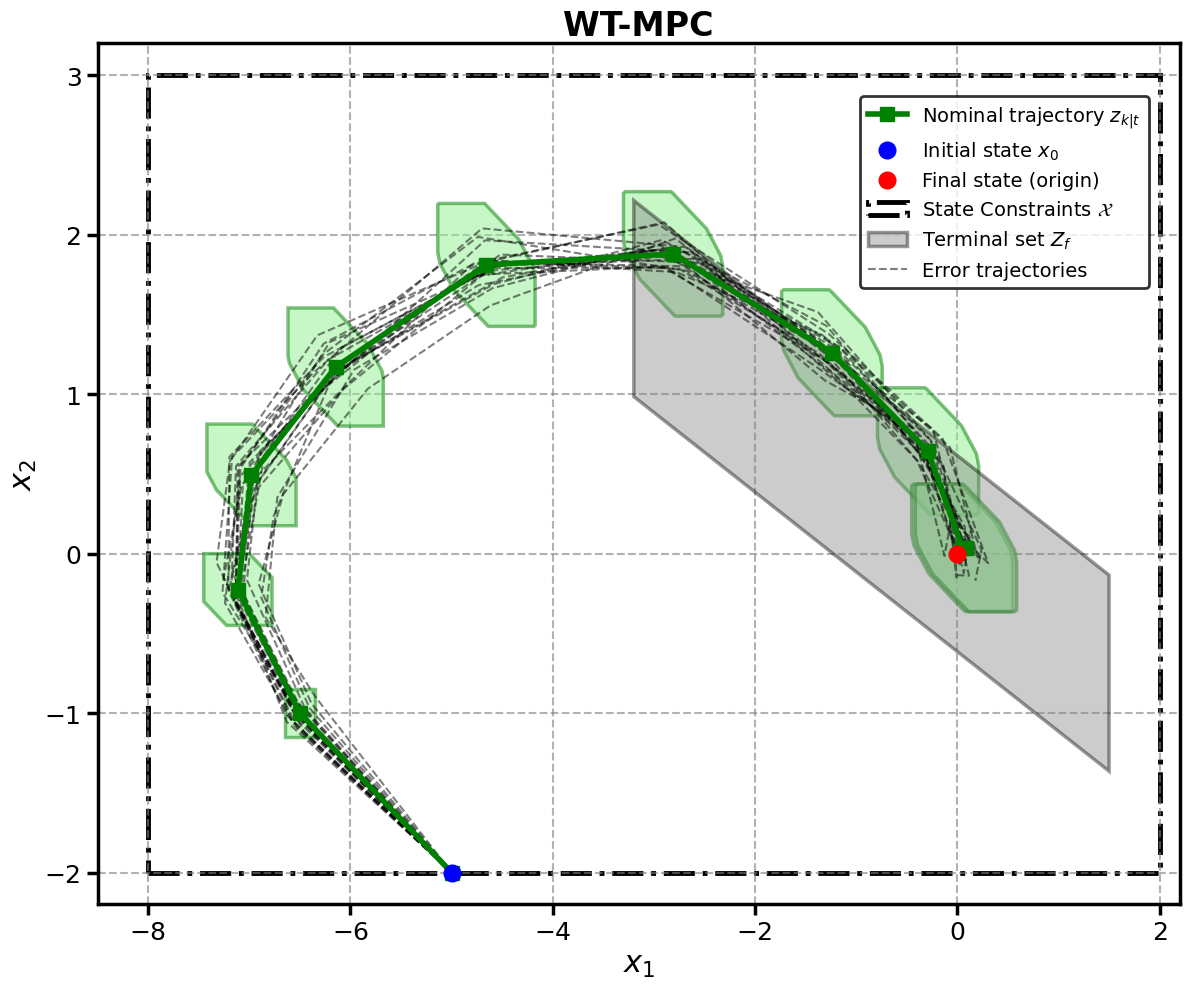

Plot saved as 'wt_mpc.png'


In [14]:
import matplotlib.pyplot as plt
import itertools
from scipy.spatial import ConvexHull
import matplotlib.patches as mpatches
import numpy as np


n_traj = 20
n0_samples = 100
epsilon = 0.1  
fig, ax = plt.subplots(figsize=(12, 10))


for e_traj in error_trajs_rt[:20]:
    traj_rt = z_wt.T + e_traj
    ax.plot(traj_rt[:, 0], traj_rt[:, 1], 'k--', alpha=0.5, linewidth=1.5, zorder=5, 
            label='Error trajectories' if 'Error trajectories' not in ax.get_legend_handles_labels()[1] else "")


for k in range(0, N+1):
    E_vertices = robust_tube(k, A_K, W_bounds)
    if E_vertices.shape[0] > 2:
        try:
            hull = ConvexHull(E_vertices)
            vertices = E_vertices[hull.vertices]
            vertices_wt = vertices  + z_wt[:, k]
            vertices_wt = np.vstack([vertices_wt, vertices_wt[0]])
            ax.fill(vertices_wt[:, 0], vertices_wt[:, 1], 
                   color='lightgreen', alpha=0.5, edgecolor='green', linewidth=2.5, zorder=3)
        except:
            pass


if A_f is not None and b_f is not None:
    candidate_vertices = []
    n_constraints = A_f.shape[0]
    
    for i, j in itertools.combinations(range(n_constraints), 2):
        A_ij = A_f[[i, j], :]
        b_ij = b_f[[i, j]]
        if np.abs(np.linalg.det(A_ij)) > 1e-8:
            v = np.linalg.solve(A_ij, b_ij)
            if np.all(A_f @ v <= b_f + 1e-6):
                candidate_vertices.append(v)
                
    if len(candidate_vertices) >= 3:
        candidate_vertices = np.array(candidate_vertices)
        hull = ConvexHull(candidate_vertices)
        ordered_vertices = candidate_vertices[hull.vertices]
        
        
        poly_patch = mpatches.Polygon(ordered_vertices, closed=True, 
                                      facecolor='gray', edgecolor='black', 
                                      alpha=0.4, linewidth=2.5, label='Terminal set $Z_f$', zorder=4)
        ax.add_patch(poly_patch)
    else:
        print("Warning: Could not construct terminal set polytope.")


ax.plot(z_wt[0, :], z_wt[1, :], 'g-', linewidth=4, label='Nominal trajectory $z_{k|t}$', marker='s', markersize=10, zorder=5)
ax.plot(0, 0, 'ro', label='Final state (origin)', markersize=12, zorder=6)
ax.plot(x0[0], x0[1], 'bo', label='Initial state $x_0$', markersize=12, zorder=6)

state_vertices = np.array([
    [-8, -2],  
    [2, -2],   
    [2, 3],   
    [-8, 3]  
])


state_poly = mpatches.Polygon(state_vertices, closed=True, 
                              facecolor='none',       
                              edgecolor='black', 
                              linestyle='-.', 
                              linewidth=3.5, 
                              label='State Constraints $\\mathcal{X}$', 
                              zorder=0)
ax.add_patch(state_poly)
ax.set_xlabel('$x_1$', fontsize=22, fontweight='bold')
ax.set_ylabel('$x_2$', fontsize=22, fontweight='bold')
ax.set_title('WT-MPC', fontsize=24, fontweight='bold')


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
desired_order = [
    'Nominal trajectory $z_{k|t}$',
    'Initial state $x_0$',
    'Final state (origin)',
    'State Constraints $\\mathcal{X}$',
    'Terminal set $Z_f$',
    'Error trajectories'
]
ordered_handles = [by_label[label] for label in desired_order if label in by_label]
ordered_labels = [label for label in desired_order if label in by_label]

leg = ax.legend(ordered_handles, ordered_labels, fontsize=14, loc='upper right', bbox_to_anchor=(0.98, 0.95))
leg.set_zorder(6)
leg.get_frame().set_linewidth(2) 
leg.get_frame().set_edgecolor('black')

ax.grid(True, alpha=0.6, color='gray', linewidth=1.5, linestyle='--', zorder=0)


ax.set_xlim(-8.5, 2.2)
ax.set_ylim(-2.2, 3.2)
ax.set_aspect('auto')


for spine in ax.spines.values():
    spine.set_linewidth(2.5)


ax.tick_params(axis='both', which='major', labelsize=18, width=2.5, length=8)

plt.tight_layout()
# plt.savefig('wt_mpc.png', dpi=600, bbox_inches='tight')
plt.show()

print("Plot saved as 'wt_mpc.png'")